In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax.config import config

from inference.fitz_ocmcmc import fitz_ocmcmc
from inference.fitz_inference import fitz_inference
from inference.theta_plot import *
from rodeo.ibm import ibm_init
from rodeo.ode import *
config.update("jax_enable_x64", True)

def fitz(X_t, t, theta):
    "Fitz ODE written for jax"
    a, b, c = theta
    V, R = X_t[:, 0]
    return jnp.array([[c*(V - V*V*V/3 + R)],
                      [-1/c*(V - a + b*R)]])

In [2]:
n_vars = 2  # number of system variables
# number of continuous derivatives per variable
n_deriv = jnp.array([3] * n_vars)
sigma = jnp.array([.1] * n_vars)  # IBM process scale factor per variable

# time interval on which solution is sought
tmin = 0.
tmax = 40.

W = jnp.array([[[0., 1., 0.]], [[0., 1., 0.]]])  # ODE LHS matrix
x0 = jnp.array([[-1., 1., 0.], [1., 1/3, 0.]])  # IVP initial value

# logprior parameters
theta_true = jnp.array([0.2, 0.2, 3]) # True theta
n_phi = 5
phi_mean = jnp.zeros(n_phi)
phi_sd = jnp.log(10)*jnp.ones(n_phi) 

noise_sigma = 0.2  # Standard deviation in noise model
dt_obs = 1.0  # Time between observations

# Number of samples to draw from posterior
n_samples = 100000

# Initialize inference class and simulate observed data
key = jax.random.PRNGKey(0)
mask = range(2)
n_theta = len(theta_true)
tseq = np.linspace(tmin, tmax, 41)
ode0 = x0[:, 0]

inf = fitz_inference(key, fitz, W, tmin, tmax, phi_mean, phi_sd, mask, noise_sigma, n_theta)
inf.n_res = 100
inf.prior_pars = ibm_init(1/inf.n_res, n_deriv, sigma)
inf.n_steps = int((tmax-tmin)*inf.n_res)
Y_t, X_t = inf.simulate(x0, theta_true)

In [12]:

mcmc = fitz_ocmcmc(key, fitz, W, tmin, tmax, phi_mean, phi_sd, Y_t, n_theta, noise_sigma)
n_res_list = np.array([10, 20, 50, 100])
phi_init = jnp.append(jnp.log(theta_true), ode0)
i = -1
prior_pars = ibm_init(1/n_res_list[i], n_deriv, sigma)
n_steps = int((tmax-tmin)*n_res_list[i])
mcmc.n_steps = n_steps
mcmc.n_res = n_res_list[i]
mcmc.prior_pars = prior_pars

In [13]:
sim = mcmc.oc_solve(key, phi_init)

In [14]:
phi_sample = mcmc.mcmc_sample(phi_init, n_samples)

In [15]:
phi_sample

DeviceArray([[-1.61465205, -1.69609772,  1.10124437, -1.01507137,
               1.0097244 ],
             [-1.61465205, -1.69609772,  1.10124437, -1.01507137,
               1.0097244 ],
             [-1.61465205, -1.69609772,  1.10124437, -1.01507137,
               1.0097244 ],
             ...,
             [-1.50748135, -3.70056461,  1.10199179, -0.91493966,
               0.93350881],
             [-1.50748135, -3.70056461,  1.10199179, -0.91493966,
               0.93350881],
             [-1.50748135, -3.70056461,  1.10199179, -0.91493966,
               0.93350881]], dtype=float64)

<AxesSubplot:ylabel='Density'>

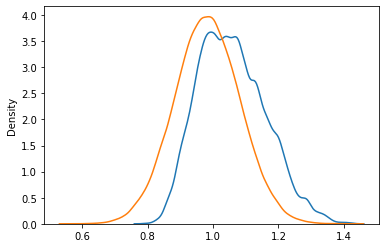

In [23]:
# plotting
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

j=4
sns.kdeplot((phi_sample[:, j]))
sns.kdeplot(theta_kalman[-1, :, j])

In [18]:
theta_kalman = np.load('saves/fitz_theta_kalman.npy')


In [2]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
from jax import jacfwd, jacrev
from jaxopt import ScipyMinimize

from rodeo.ibm import ibm_init
from rodeo.ode import solve_mv, interrogate_rodeo

def fitz(X_t, t, theta):
    "FitzHugh-Nagumo ODE."
    a, b, c = theta
    V, R = X_t[:, 0]
    return jnp.array([[c*(V - V*V*V/3 + R)],
                      [-1/c*(V - a + b*R)]])

# --- data simulation ------------------------------------------------------
# Produce a Pseudo-RNG key
key = jax.random.PRNGKey(0)
key, *subkeys = jax.random.split(key, num=3) # split keys to not reuse

W = jnp.array([[[0., 1., 0.]], [[0., 1., 0.]]])  # LHS matrix of ODE
x0 = jnp.array([[-1., 1., 0.], [1., 1/3, 0.]])  # initial value for the IVP
theta = jnp.array([.2, .2, 3])  # ODE parameters

# Time interval on which a solution is sought.
tmin = 0.
tmax = 40.
dt_obs = 1  # Time between observations

# Define the prior process
n_vars = 2
n_deriv = jnp.array([3] * n_vars)

# IBM process scale factor
sigma = jnp.array([.1] * n_vars)

# use large number for accurate solution
# higher resolution means smaller step size
n_res = 100  # resolution number; 
n_steps = int(n_res*(tmax-tmin)/dt_obs)
dt = (tmax-tmin)/n_steps  # step size
prior_pars = ibm_init(
    dt=dt,
    n_deriv=n_deriv,
    sigma=sigma
)

# generate the Kalman parameters corresponding to the prior
prior_pars = ibm_init(dt=dt,
                      n_deriv=n_deriv,
                      sigma=sigma)

# deterministic output: posterior mean
mut, Sigmat = solve_mv(key=subkeys[0],
                       # define ode
                       fun=fitz,
                       W=W,
                       x0=x0,
                       theta=theta,
                       tmin=tmin,
                       tmax=tmax,
                       # solver parameters
                       n_steps=n_steps,
                       interrogate=interrogate_rodeo,
                       **prior_pars)

# Generate observations
noise_sd = 0.2  # Standard deviation in noise model
Xt = mut[::n_res, :, 0]
et = jax.random.normal(key=subkeys[1], shape = Xt.shape)
Yt = Xt + noise_sd*et

In [10]:

# parameter prior
n_phi = 5  # number of parameters + initial values to estimate
phi_mean = jnp.zeros((n_phi,))
phi_sd = jnp.log(10) * jnp.ones((n_phi,))

def fitz_logpost(phi, key):
    """
    Logposterior for FN model.

    Args:
        phi: Transformed parameters and initial values for the FN model: 
             `phi = (log a, log b, log c, V0, R0)`.
        key: JAX PRNG key.

    Returns:
        The logposterior.
    """
    # solve ODE
    theta = jnp.exp(phi[0:3])  # convert parameters to original scale
    x0 = jnp.expand_dims(phi[3:5], 1)
    v0 = fitz(x0, 0, theta)
    # padded initial values for rodeo
    x0 = jnp.hstack([x0, v0, jnp.zeros(shape=(x0.shape))]) 
    Xt, _ = solve_mv(
        key=key,
        fun=fitz,
        W=W,
        x0=x0,
        theta=theta,
        tmin=tmin,
        tmax=tmax,
        interrogate=interrogate_rodeo,
        n_steps=n_steps,
        **prior_pars
    )
    # compute the loglikelihood and the log-prior
    loglik = jnp.sum(jsp.stats.norm.logpdf(
        x=Yt,
        loc=Xt[::n_res, :, 0],  # thin solver output
        scale=noise_sd
    ))
    logprior = jnp.sum(jsp.stats.norm.logpdf(
        x=phi,
        loc=phi_mean,
        scale=phi_sd
    ))
    return loglik + logprior

# rodeo initial parameters
n_res = 10  # resolution number
n_steps = int(n_res*(tmax-tmin)/dt_obs)
dt = (tmax-tmin)/n_steps  # step size
prior_pars = ibm_init(
    dt=dt,
    n_deriv=n_deriv,
    sigma=sigma
)
key, key2 = jax.random.split(key)

# mode finding using jaxopt
# suppose observations are given by Yt

# jits the objective function
solver = ScipyMinimize(method="Newton-CG", fun=fitz_logpost, jit=True) 

# run jaxopt to find mode
phi_init = jnp.ones((n_phi,))
opt_res = solver.run(phi_init, key=key)
phi_hat = opt_res.params

# hessian computation
hes = jacfwd(jacrev(fitz_logpost))
phi_fisher = hes(phi_hat, key)
phi_cho, low = jsp.linalg.cho_factor(phi_fisher)
phi_var = jsp.linalg.cho_solve((phi_cho, low), jnp.eye(n_phi))

# sample posteriors
n_samples = 100000
phi_post = jax.random.multivariate_normal(
    key=key2, mean=phi_hat, cov=phi_var, shape=(n_samples,))
theta_post = jnp.concatenate([jnp.exp(phi_post[:, :3]), phi_post[:, 3:]], axis=1)
